# INTRODUCTION 

First we will import the important libraries for the data

In [12]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sqlite3

In [5]:
# Now we will load the data 
df = pd.read_csv('student_performance_dataset.csv')
print(df.head())

   student_id  gender  study_time_hours  attendance_percent  sleep_hours  \
0           1    Male               4.0                98.0          6.5   
1           2  Female               6.3               100.0          5.7   
2           3    Male               4.9                85.3          7.9   
3           4    Male               2.6                77.5          8.0   
4           5    Male               2.2                89.6          4.6   

  parental_education internet_access extracurricular_activities part_time_job  \
0          Bachelors             Yes                        Yes            No   
1        High School             Yes                        Yes           Yes   
2          Bachelors             Yes                         No           Yes   
3                NaN             Yes                        Yes            No   
4          Bachelors             Yes                         No           Yes   

   previous_grade  final_exam_score final_grade  
0     

This data is about the performance of students in exams according to there study tie attendence sleep hours and many more .
* It also provides us the information about their internet access if they can get that or not which might relate to the score and sleep hour of some students
* Parental education means the education or highest qualification person's paent have 
* The meaning of extracurricular activities is the activities performed outside of ragular class
* This data also provides if the student have a part time job or not .

For the first step we will use the info function in our data to get the number of null values and the data types of the rows 

# INFO AND STATITICS

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   str    
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    str    
 6   internet_access             1000 non-null   str    
 7   extracurricular_activities  1000 non-null   str    
 8   part_time_job               1000 non-null   str    
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   str    
dtypes: float64(5), int64(1), str(6)
memory usage: 93.9 KB


In [9]:
# As we can see here that the parental education row have some null values .

Now we will use the describe function for the better analysis and statatics 

In [10]:
print(df.describe())

        student_id  study_time_hours  attendance_percent  sleep_hours  \
count  1000.000000       1000.000000         1000.000000  1000.000000   
mean    500.500000          3.570700           85.092300     6.799500   
std     288.819436          1.478559            9.270685     1.203527   
min       1.000000          0.500000           54.800000     3.200000   
25%     250.750000          2.600000           78.800000     5.900000   
50%     500.500000          3.600000           85.200000     6.800000   
75%     750.250000          4.500000           91.900000     7.600000   
max    1000.000000          8.100000          100.000000    10.000000   

       previous_grade  final_exam_score  
count     1000.000000       1000.000000  
mean        69.740900         83.543500  
std         12.613425         10.341333  
min         31.300000         46.800000  
25%         61.000000         76.075000  
50%         69.600000         83.800000  
75%         78.400000         91.525000  
max   

# CLEANING

In [34]:
df['parental_education'] = df['parental_education'].fillna('Unknown')
print('cleaning completed !')

cleaning completed !


The statitics shows - 
* The average study time is 3 hours and minimum is 0.5 which means 30 minutes
* average sleep hour is 6 hour and minimum is 3 hours
* minimum attendence percentage is 54% 

# SQL

In [14]:
# Now we will use SQL  to get the key information from data

# SETTING UP SQL 
conn = sqlite3.connect('student_health_db')
df.to_sql('student_data',conn,index = False, if_exists = 'replace')

1000

In [29]:
# I will answer questions with every query 

# Question 1 - Average study time of student with internet access ? 
query1 = 'SELECT "internet_access" , AVG("study_time_hours") as average_study_time FROM student_data GROUP BY internet_access ORDER BY average_study_time DESC'
print(pd.read_sql_query(query1,conn))

# Question 2 - Study time of people with the part time jobs ?
query2 = 'SELECT "part_time_job" , AVG("study_time_hours") as average_study_time FROM student_data GROUP BY part_time_job'
print(pd.read_sql_query(query2,conn))

# Question 3 - Who did better in final exam , male or female ? 
query3 = 'SELECT "gender" , AVG("final_exam_score") as final_score FROM student_data GROUP BY gender ORDER BY final_score DESC'
print(pd.read_sql_query(query3,conn))

# Final Question - Aveage study time with final grades 
query4 = 'SELECT "final_grade" , AVG("study_time_hours") as avg_study_time FROM student_data GROUP BY final_grade ORDER BY avg_study_time DESC'
print(pd.read_sql_query(query4,conn))

  internet_access  average_study_time
0              No            3.589726
1             Yes            3.567447
  part_time_job  average_study_time
0            No            3.589766
1           Yes            3.529430
   gender  final_score
0  Female    83.606863
1    Male    83.477551
  final_grade  avg_study_time
0           A        4.645423
1           B        3.592938
2           C        2.877011
3           D        2.302247
4           F        1.975000


# SQL RESULTS

**SQL Query Results & Insights**

* **Internet Access & Study Time:** There is minimal difference in study time between students with internet access and those without, indicating that the majority of students do not let internet access negatively impact their study habits.
* **Part-Time Employment:** Students with part-time jobs log nearly the same study time as those without part-time employment.
* **Gender & Academic Performance:** Grade differences between male and female students are very slight; however, female students remain slightly ahead of male students.
* **Study Time vs. Performance:** Students with lower grades dedicate noticeably less time to studying, aligning with expectations.

# PANDAS

In [30]:
# Now we will use pandas for key info we will mainly use it for the value counts 

In [40]:
final_grade_count = df['final_grade'].value_counts()
print(final_grade_count)

gender_count = df['gender'].value_counts()
print(gender_count)

toppers = df['final_exam_score'].where(df['final_exam_score'] > 79.9).dropna()
print('number of toppers :',len(toppers))

less_sleep = df['sleep_hours'].where(df['sleep_hours'] < 4).dropna()
print('student with bad sleep schedule :',len(less_sleep))

final_grade
B    354
A    284
C    261
D     89
F     12
Name: count, dtype: int64
gender
Female    510
Male      490
Name: count, dtype: int64
number of toppers : 638
student with bad sleep schedule : 8


# PANDAS RESULTS AND INSIGHTS

SQL Query Results & Insights

Grade Distribution: Out of 1,000 students, the majority achieved a B grade (354), followed by 284 students with an A grade. Only 12 students failed.

Gender Demographics: The student population consists of 510 females and 490 males.

High Performers: A total of 638 students scored above 79.9%.

Sleep Patterns: Only 8 students reported a poor sleep schedule of less than 4 hours.

# PLOTTING

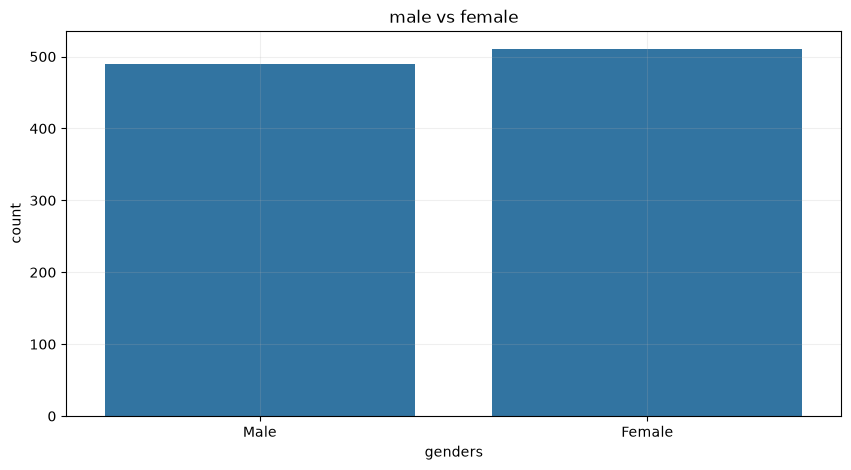

In [65]:
# first is count plot for genders
plt.figure(figsize = (10,5))
sns.countplot(data = df , x = 'gender')
plt.xlabel('genders')
plt.ylabel('count')
plt.title('male vs female')
plt.grid(True,alpha = 0.2)
plt.show()


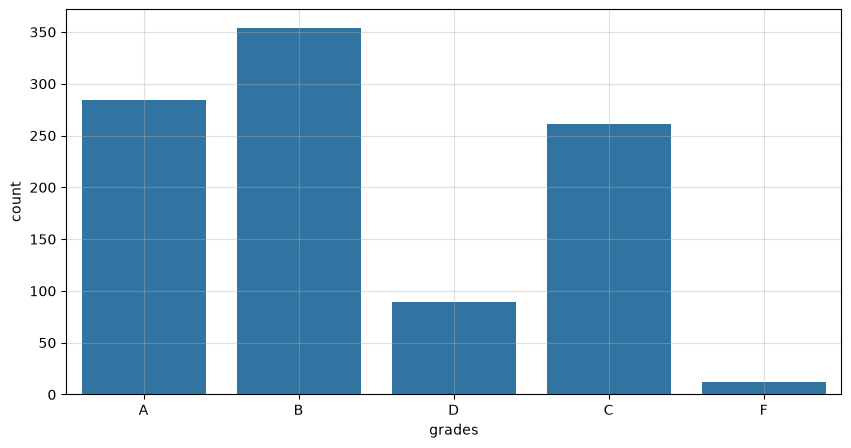

In [50]:
plt.figure(figsize = (10,5))
sns.countplot(data = df , x = 'final_grade')
plt.xlabel('grades')
plt.ylabel('count')
plt.grid(True,alpha = 0.4)
plt.show()

B have the highest count 

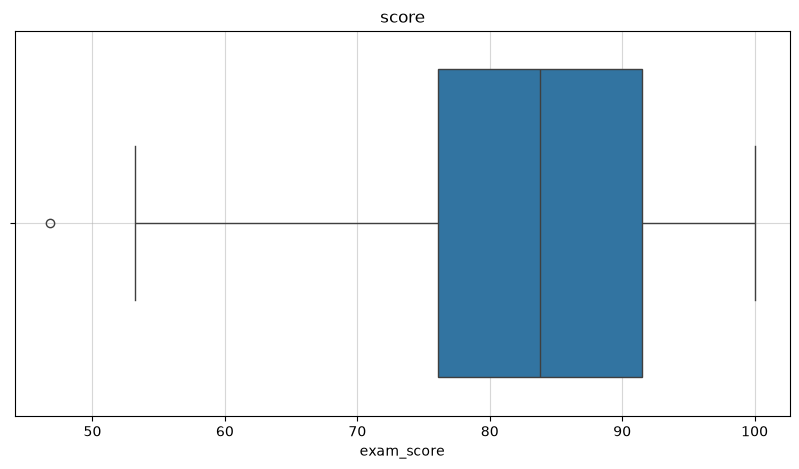

In [63]:
plt.figure(figsize = (10,5))
sns.boxplot(data = df , x = 'final_exam_score')
plt.xlabel('exam_score')
plt.title('score')
plt.grid(True,alpha = 0.5)
plt.show()

This box plot shows that there is only one outlier in the whole data 

# CORRELATION HEATMAP

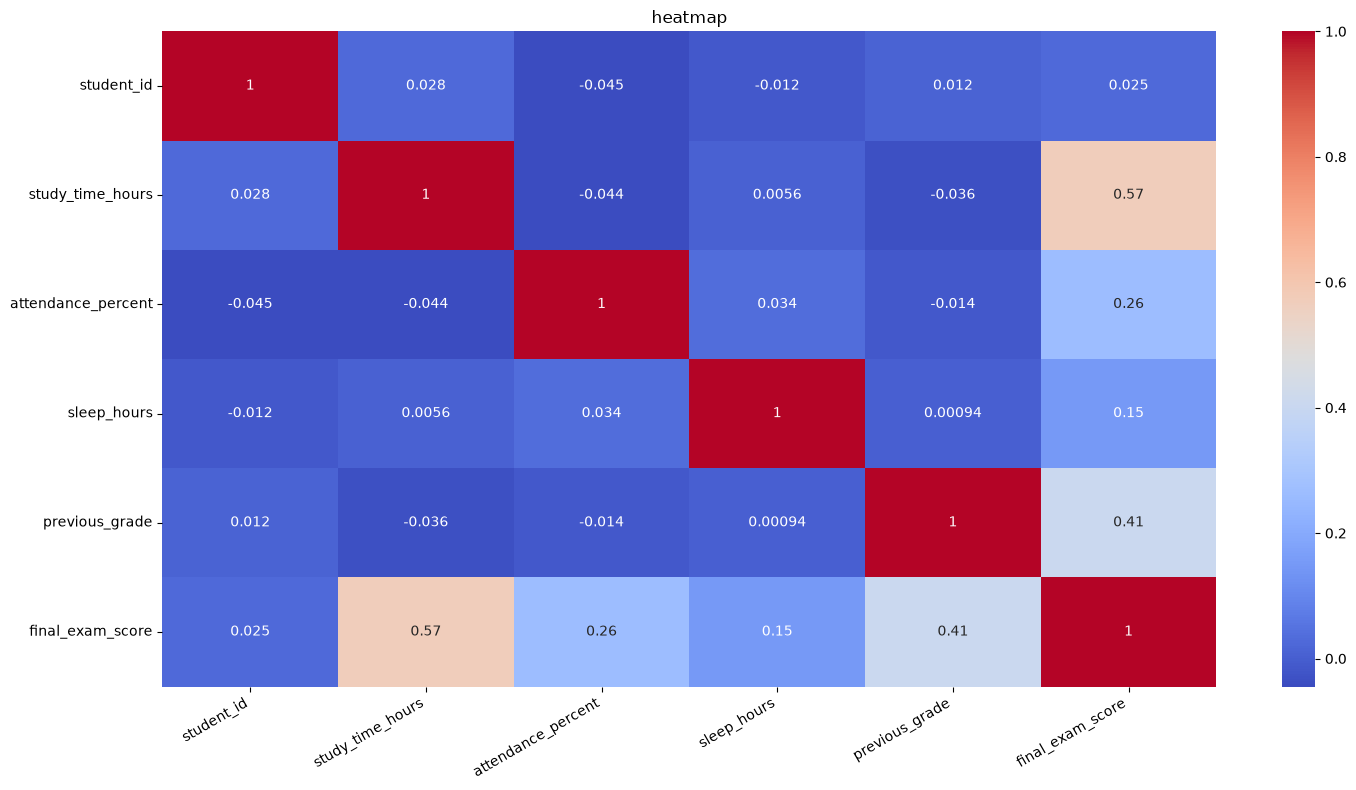

In [55]:
# first we will check the correlation by using the heatmap 
corr = df.corr(numeric_only = True)

plt.figure(figsize = (15,8))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title('heatmap')
plt.xticks(rotation = 390 , ha = 'right')
plt.tight_layout()
plt.show()

Key SQL Insight

Single Strong Correlation: Across the entire dataset, the only strong, clear correlation present is between daily study time and student grades; all other factors show negligible impact.

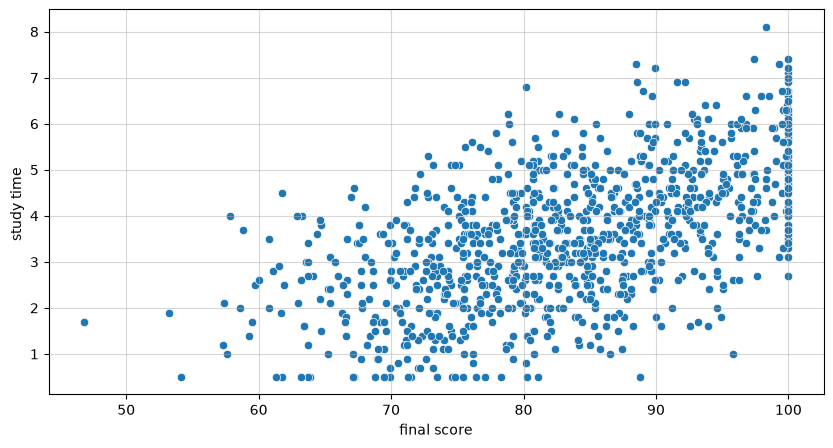

In [57]:
plt.figure(figsize = (10,5))
sns.scatterplot(data = df , x = 'final_exam_score' , y = 'study_time_hours')
plt.xlabel('final score')
plt.ylabel('study time ')
plt.grid(True,alpha = 0.5)
plt.show()

It has very good relation and also very obvious

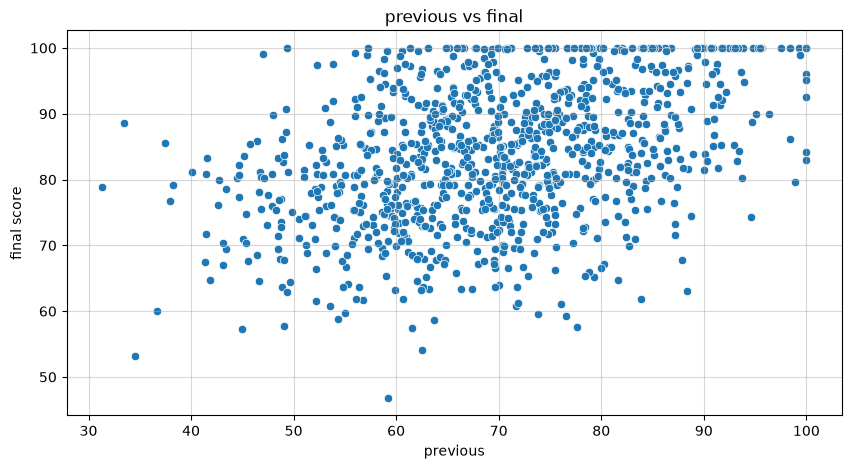

In [62]:
plt.figure(figsize = (10,5))
sns.scatterplot(data= df , x = 'previous_grade' , y = 'final_exam_score')
plt.xlabel('previous')
plt.ylabel('final score')
plt.title('previous vs final')
plt.grid(True,alpha = 0.5)
plt.show()

This have a very good relation 

In [71]:
# Machine learning model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [102]:
x = df[['sleep_hours','study_time_hours','attendance_percent','previous_grade']]
y = df['final_exam_score']

x_train,x_test,y_train,y_test = train_test_split(x,
                             y,
                             test_size = 0.2,
                             random_state = 777)
model = LinearRegression()
model.fit(x_train,y_train)

prediction = model.predict([[8,6,80,88]])
print(prediction)

y_pred = model.predict(x_test)

score = r2_score(y_test,y_pred)
print(score)

[99.95422123]
0.6179083963379945


C:\Users\lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


The model achieved a strong prediction score of **61.79%** ($R^2$), yielding a target prediction of approximately **99.95**.

# FINAL VERDICT 

**Final Data Analysis Verdict**

* **Primary Success Factor:** **Study time is the single defining driver of academic achievement.** It is the only metric with a strong direct correlation to final grades, proving that personal effort outweighs all external circumstances.
* **Minimal External Distractions:** Factors like **internet access and part-time employment show no negative impact** on study habits, indicating that students generally manage their time and digital access responsibly.
* **Strong Overall Academic Health:** The dataset reflects a highly successful student body—over **63% of students scored above 80%**, and **only 1.2% failed**. Demographic factors like gender showed no meaningful performance gap.
* **Model Predictive Reliability:** The predictive model achieves a **61.79% accuracy score ($R^2$)**, confirming that while study hours explain the majority of performance variance, unmeasured factors (e.g., study quality or baseline knowledge) account for the rest.